# iFFT to create signal with given Spectrum
## Investigate filtering

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

from scipy.signal import chirp, spectrogram, windows, butter, filtfilt, freqz, lfilter
from scipy.fftpack import fft, ifft, fftfreq, fftshift, ifftshift
from scipy.io.wavfile import write 


## Flat Spectrum - Set Parameters 

In [4]:
Td = 2
fs = 44100
N = 2**(1+round(np.log2(Td*fs)))
#N = 4096; 
print('N = '+str(N))
T = N/fs
t = np.arange(N)*T/N
delta_freq = fs/N

N = 131072


In [5]:
# bounds of rect in Y(f)
f_low = 1000
f_high = 4000
# find equivalent positions in Y(f) 
n_low = int(f_low/delta_freq)
n_high = int(f_high/delta_freq)
L1 = np.arange(n_low,n_high)

## Create Y(f) and y[n]

In [6]:
Y_bl = np.zeros((N,), dtype=complex)
# create random phase needed for correct ifft process
rng = np.random.default_rng()
phi = rng.uniform(0, 2*np.pi, (len(L1),))

# create Y(f)
mag_temp = np.ones([1,n_high-n_low])
    
Y_bl[L1] = mag_temp*np.exp(1j*phi)
# add complex conjugate at upper end to ensure that y[n] real
Y_bl[N-L1] = np.conj(Y_bl[L1])

# create y[n]
y_bl = ifft(Y_bl)

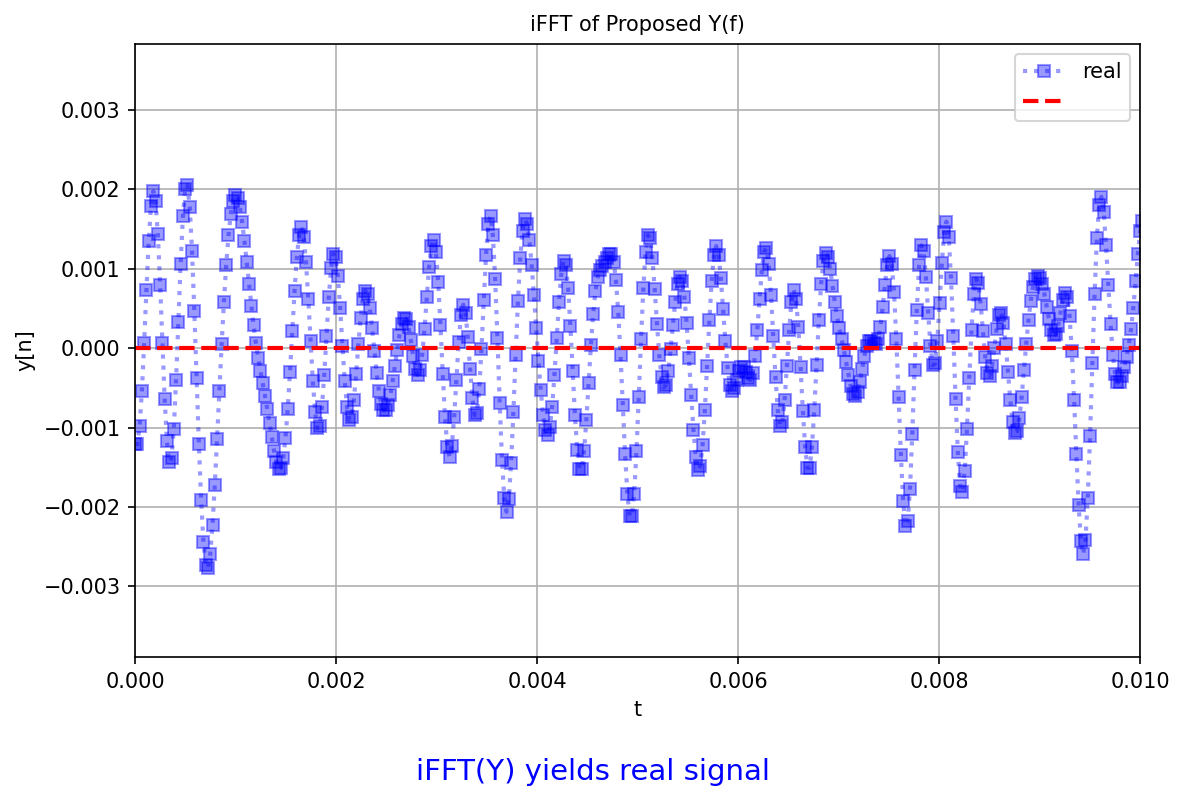

In [7]:
# check that it is real
fig = plt.figure(figsize=(8,5), dpi=150)
plt.plot(t[0:n_low], y_bl.real[0:n_low], 'bs:', alpha=0.4)
plt.plot(t[0:n_low], y_bl.imag[0:n_low], 'r--')
plt.xlabel('t')
plt.ylabel('y[n]')
plt.xlim(0,.01)
plt.legend(('real', '', 'imaginary'))
plt.title('iFFT of Proposed Y(f)')
bm.caption("iFFT(Y) yields real signal",fig)
plt.show()

## FFT the created data to confirm spectrum is right

In [8]:
Y_bl_fft = fft(y_bl)
f_bl = fftfreq(N, 1/fs)

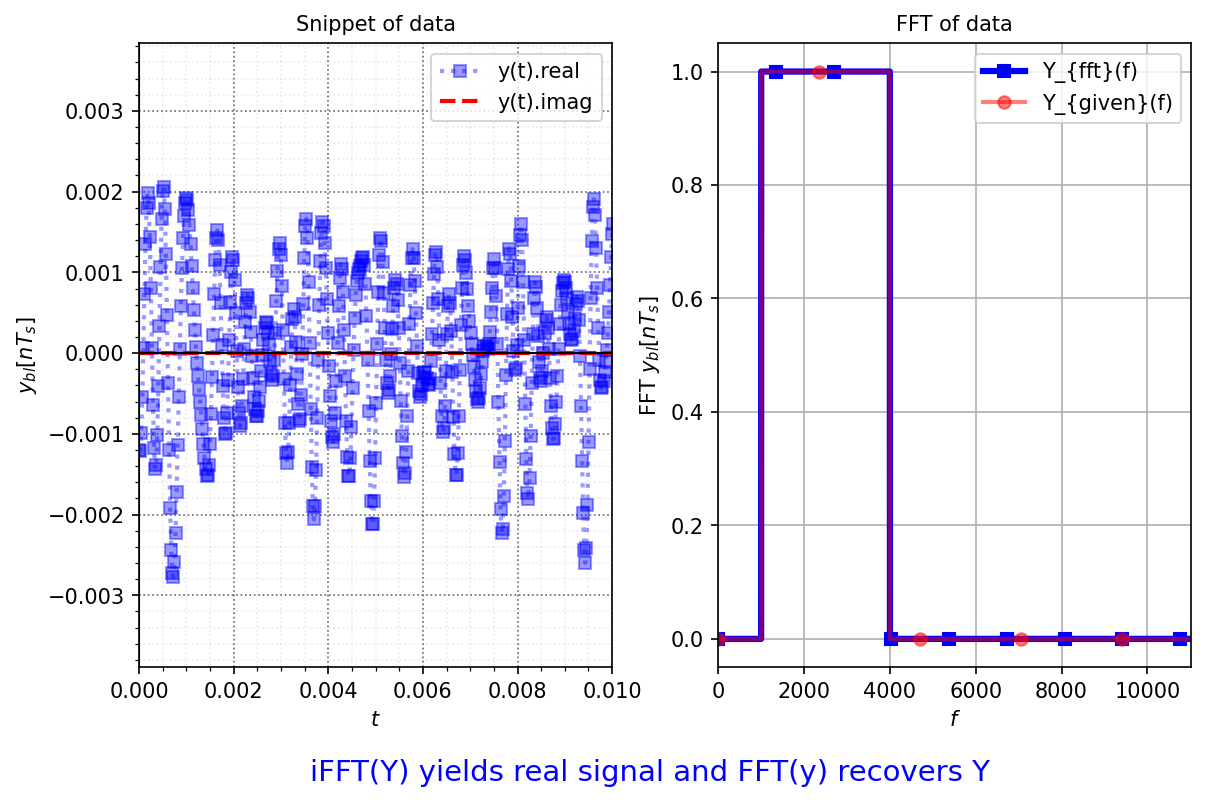

In [9]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
fig.tight_layout(pad=2)
ax1.plot(t[0:n_low], y_bl.real[0:n_low], 'bs:', alpha=0.4)
ax1.plot(t[0:n_low], y_bl.imag[0:n_low], 'r--')
ax1.set_ylabel('$y_{bl}[nT_s]$')
ax1.set_xlabel('$t$')
ax1.legend(['y(t).real','y(t).imag'])
ax1.set_title('Snippet of data')
ax1.set_xlim(0,.01)
bm.nicegrid(ax1)

ax2.plot(f_bl[0:N//2], np.abs(Y_bl_fft[0:N//2]),'bs-',lw=3,markevery=4000)
ax2.plot(f_bl[0:N//2], np.abs(Y_bl[0:N//2]),'ro-',alpha=0.5,markevery=7000)
ax2.set_ylabel('FFT $y_{bl}[nT_s]$')
ax2.set_xlabel('$f$')
ax2.set_xlim([0, fs/4])
ax2.legend(['Y_{fft}(f)','Y_{given}(f)'])
ax2.set_title('FFT of data')
bm.caption("iFFT(Y) yields real signal and FFT(y) recovers Y",fig)
plt.show()

In [10]:
file_name = 'data/ifft_csv_file_flat'+'_'+str(f_low)+'_'+str(f_high)+'_'+str(fs)+'.csv'
np.savetxt(file_name, np.real(y_bl), delimiter=',', fmt='%f')

## Apply the filters to the time data 

In [11]:
eps = 1e-12 # added to avoid some plotting errors
# Low Pass
b_low, a_low = butter(2, 2*f_low, 'low', fs=fs)
f_lp, h_lp = freqz(b_low, a_low,fs=fs,worN=1000)
# High Pass
b_high, a_high = butter(2, f_high/2, 'high', fs=fs)
f_hp, h_hp = freqz(b_high, a_high,fs=fs,worN=1000)
# Band Pass
omega1 = max(f_high/2,2*f_low)
omega0 = min(min(f_high/2,2*f_low),omega1/2)
b_bp, a_bp = butter(2, [omega0,omega1], 'bandpass', fs=fs)
f_bp, h_bp = freqz(b_bp, a_bp,fs=fs,worN=1000)

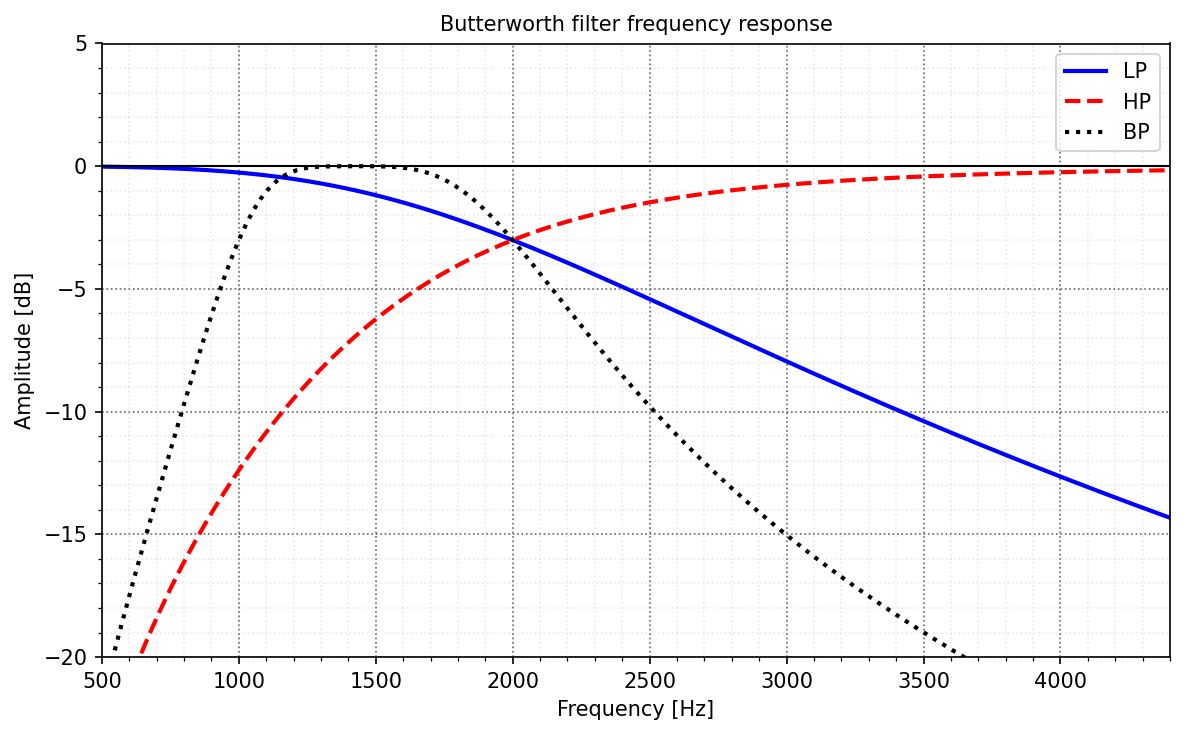

In [12]:
fig = plt.figure(figsize=(8,5), dpi=150)
plt.plot(f_lp, 20 * np.log10(abs(h_lp+eps)),'b-',label='LP')
plt.plot(f_hp, 20 * np.log10(abs(h_hp+eps)),'r--',label='HP')
plt.plot(f_bp, 20 * np.log10(abs(h_bp+eps)),'k:',label='BP')
plt.title('Butterworth filter frequency response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.xlim([f_low/2, 1.1*f_high])
plt.ylim([-20, 5])
bm.nicegrid()
plt.legend()
plt.show()

## Find Spectrum of filtered time data to confirm consistent with expectations

In [13]:
# Apply filters to data
yf_lp = lfilter(b_low, a_low, y_bl)
yf_hp = lfilter(b_high, a_high, y_bl)
yf_bp = lfilter(b_bp, a_bp, y_bl)

Y_lp_fft = fft(yf_lp)
Y_hp_fft = fft(yf_hp)
Y_bp_fft = fft(yf_bp)

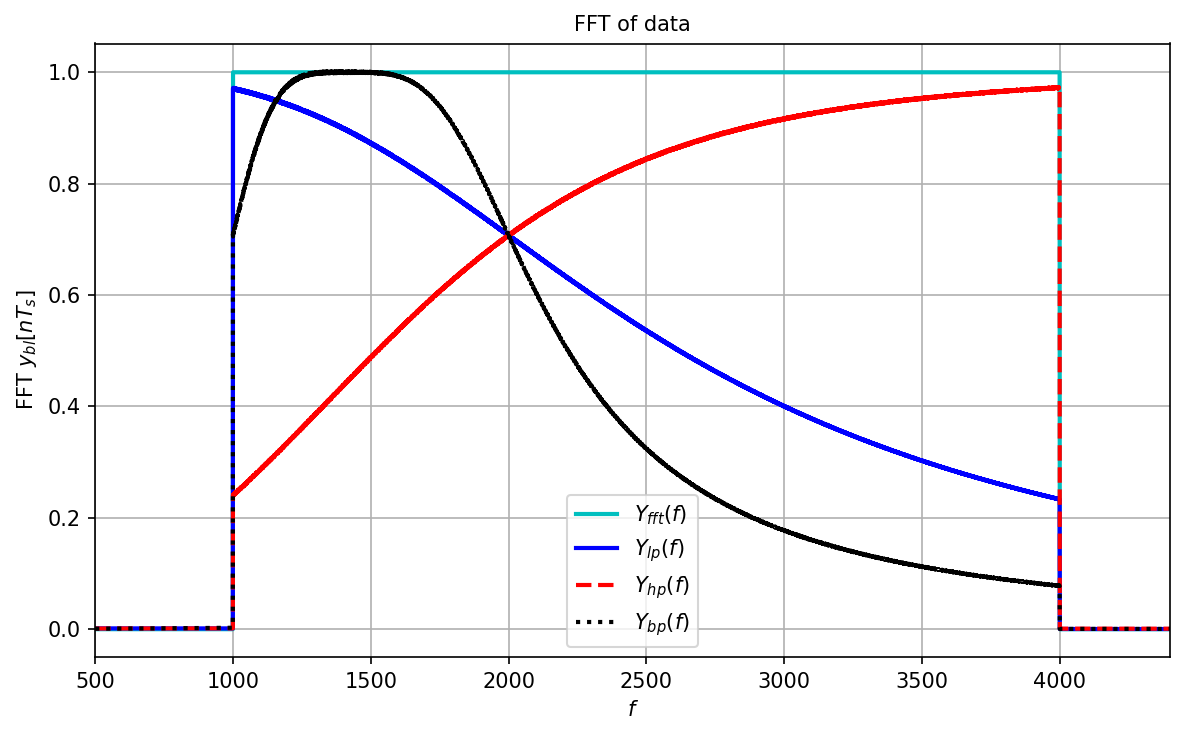

In [14]:
fig, ax1 = plt.subplots(1,1, figsize=(8,5), dpi=150)
ax1.plot(f_bl[0:N//2], np.abs(Y_bl_fft[0:N//2]),'c-')
ax1.plot(f_bl[0:N//2], np.abs(Y_lp_fft[0:N//2]),'b-')
ax1.plot(f_bl[0:N//2], np.abs(Y_hp_fft[0:N//2]),'r--')
ax1.plot(f_bl[0:N//2], np.abs(Y_bp_fft[0:N//2]),'k:')
ax1.set_ylabel(r'FFT $y_{bl}[nT_s]$')
ax1.set_xlabel('$f$')
ax1.set_xlim([int(f_low)/2, 1.1*int(f_high)])
ax1.legend([r'$Y_{fft}(f)$', r'$Y_{lp}(f)$', r'$Y_{hp}(f)$', r'$Y_{bp}(f)$'])
ax1.set_title('FFT of data')
plt.show()

In [15]:
from scipy.io.wavfile import write 
import IPython.display as ipd
from numpy import max, real, float32  # Ensure necessary imports
write("data/y_fft_flat.wav", fs, (real(y_bl) / max(abs(y_bl))).astype(float32))
ipd.Audio("data/y_fft_flat.wav", rate=fs)


In [16]:
write("data/yf_lp_fft_flat.wav", fs, np.real(yf_lp/max(yf_lp)).astype(np.float32))
ipd.Audio('data/yf_lp_fft_flat.wav', rate = fs) # 

In [17]:
write("data/yf_hp_fft_flat.wav", fs, np.real(yf_hp/max(yf_hp)).astype(np.float32))
ipd.Audio('data/yf_hp_fft_flat.wav', rate = fs) # 

In [18]:
write("data/yf_bp_fft_flat.wav", fs, np.real(yf_bp/max(yf_bp)).astype(np.float32))
ipd.Audio('data/yf_bp_fft_flat.wav', rate = fs) # 

# Second Example

In [19]:
# bounds of rect in Y(f)
f_low = 2000
f_high = 5000
# find equivalent positions in Y(f) 
n_low = int(f_low/delta_freq)
n_high = int(f_high/delta_freq)
L1 = np.arange(n_low,n_high)

## Create Y(f) and y[n]

In [20]:
Y_bl = np.zeros((N,), dtype=complex)
# create random phase needed for correct ifft process
rng = np.random.default_rng()
phi = rng.uniform(0, 2*np.pi, (len(L1),))

# create Y(f)
mag_temp = np.sin(np.pi*np.arange(0,n_high-n_low)/(n_high-n_low))
    
Y_bl[L1] = mag_temp*np.exp(1j*phi)
# add complex conjugate at upper end to ensure that y[n] real
Y_bl[N-L1] = np.conj(Y_bl[L1])

# create y[n]
y_bl = ifft(Y_bl)

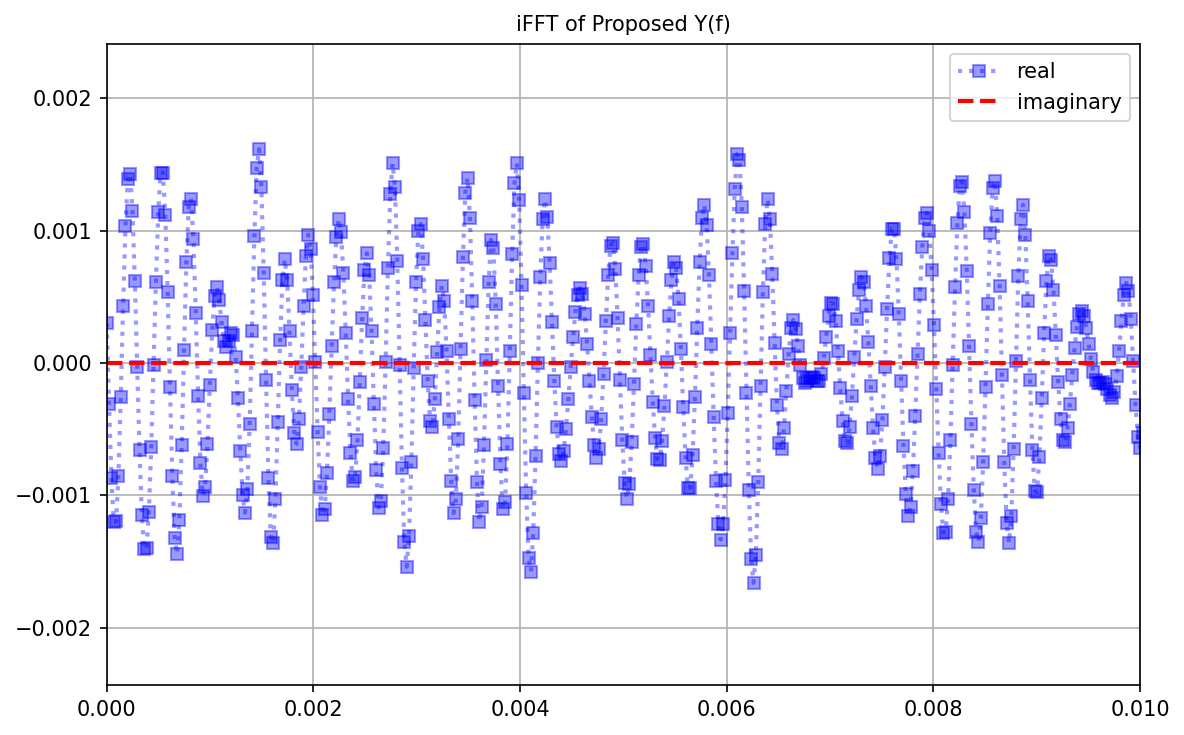

In [21]:
# check that it is real
fig = plt.figure(figsize=(8,5), dpi=150)
plt.plot(t[0:n_low], y_bl.real[0:n_low], 'bs:', alpha=0.4)
plt.plot(t[0:n_low], y_bl.imag[0:n_low], 'r--')
plt.legend(('real', 'imaginary'))
plt.xlim(0,.01)
plt.title('iFFT of Proposed Y(f)')
plt.show()

## FFT the created data to confirm spectrum is right

In [22]:
Y_bl_fft = fft(y_bl)
f_bl = fftfreq(N, 1/fs)

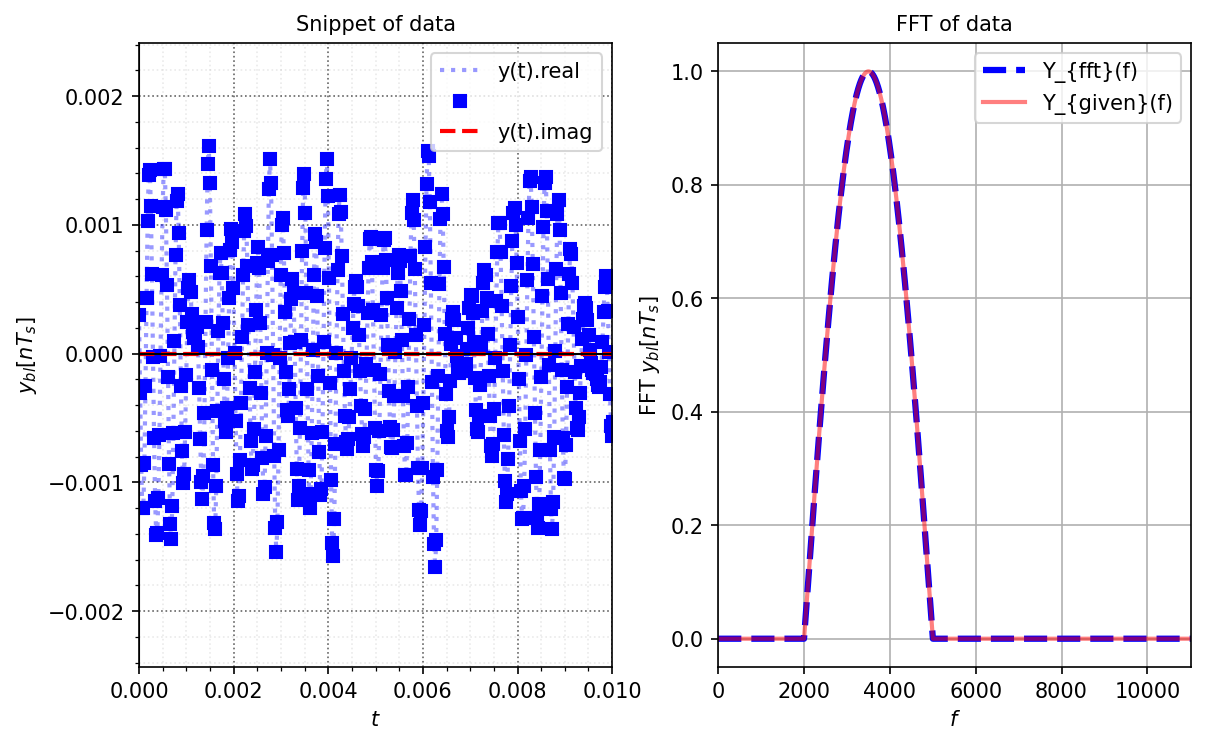

In [23]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
fig.tight_layout(pad=2)
ax1.plot(t[0:n_low], y_bl.real[0:n_low], 'b:', alpha=0.4)
ax1.plot(t[0:n_low], y_bl.real[0:n_low], 'bs')
ax1.plot(t[0:n_low], y_bl.imag[0:n_low], 'r--')
ax1.set_ylabel('$y_{bl}[nT_s]$')
ax1.set_xlabel('$t$')
ax1.legend(['y(t).real',' ','y(t).imag'])
ax1.set_title('Snippet of data')
ax1.set_xlim(0,.01)
bm.nicegrid(ax1)

ax2.plot(f_bl[0:N//2], np.abs(Y_bl_fft[0:N//2]),'b--',lw=3,markevery=4000)
ax2.plot(f_bl[0:N//2], np.abs(Y_bl[0:N//2]),'r-',alpha=0.5,markevery=7000)
ax2.set_ylabel('FFT $y_{bl}[nT_s]$')
ax2.set_xlabel('$f$')
ax2.set_xlim([0, fs/4])
ax2.legend(['Y_{fft}(f)','Y_{given}(f)'])
ax2.set_title('FFT of data')
plt.show()

In [24]:
import csv
f = open('data/ifft_csv_file_sine'+'_'+str(f_low)+'_'+str(f_high)+'_'+str(fs)+'.csv', 'w')
writer = csv.writer(f)
for i in range(len(y_bl)):
    writer.writerow([np.real(y_bl[i])])
f.close()

## Apply the filters to the time data 

In [25]:
eps = 1e-12 # added to avoid some plotting errors
# Low Pass
b_low, a_low = butter(2, f_low, 'low', fs=fs)
f_lp, h_lp = freqz(b_low, a_low,fs=fs,worN=1000)
# High Pass
b_high, a_high = butter(2, f_high, 'high', fs=fs)
f_hp, h_hp = freqz(b_high, a_high,fs=fs,worN=1000)
# Band Pass
omega1 = f_high-1000
omega0 = f_low+1000
b_bp, a_bp = butter(2, [omega0,omega1], 'bandpass', fs=fs)
f_bp, h_bp = freqz(b_bp, a_bp,fs=fs,worN=1000)

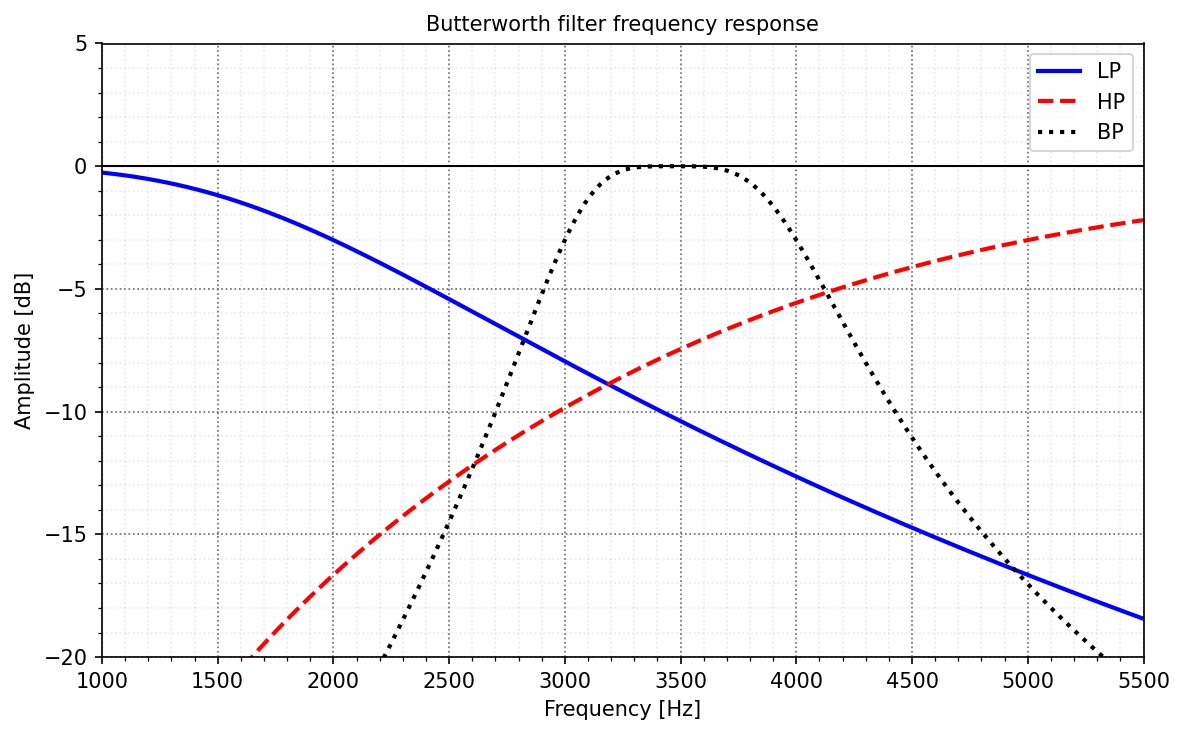

In [26]:
fig = plt.figure(figsize=(8,5), dpi=150)
plt.plot(f_lp, 20 * np.log10(abs(h_lp+eps)),'b-',label='LP')
plt.plot(f_hp, 20 * np.log10(abs(h_hp+eps)),'r--',label='HP')
plt.plot(f_bp, 20 * np.log10(abs(h_bp+eps)),'k:',label='BP')
plt.title('Butterworth filter frequency response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.xlim([f_low/2, 1.1*f_high])
plt.ylim([-20, 5])
bm.nicegrid()
plt.legend()
plt.show()

## Find Spectrum of filtered time data to confirm consistent with expectations

In [27]:
# Apply filters to data
yf_lp = lfilter(b_low, a_low, y_bl)
yf_hp = lfilter(b_high, a_high, y_bl)
yf_bp = lfilter(b_bp, a_bp, y_bl)

Y_lp_fft = fft(yf_lp)
Y_hp_fft = fft(yf_hp)
Y_bp_fft = fft(yf_bp)

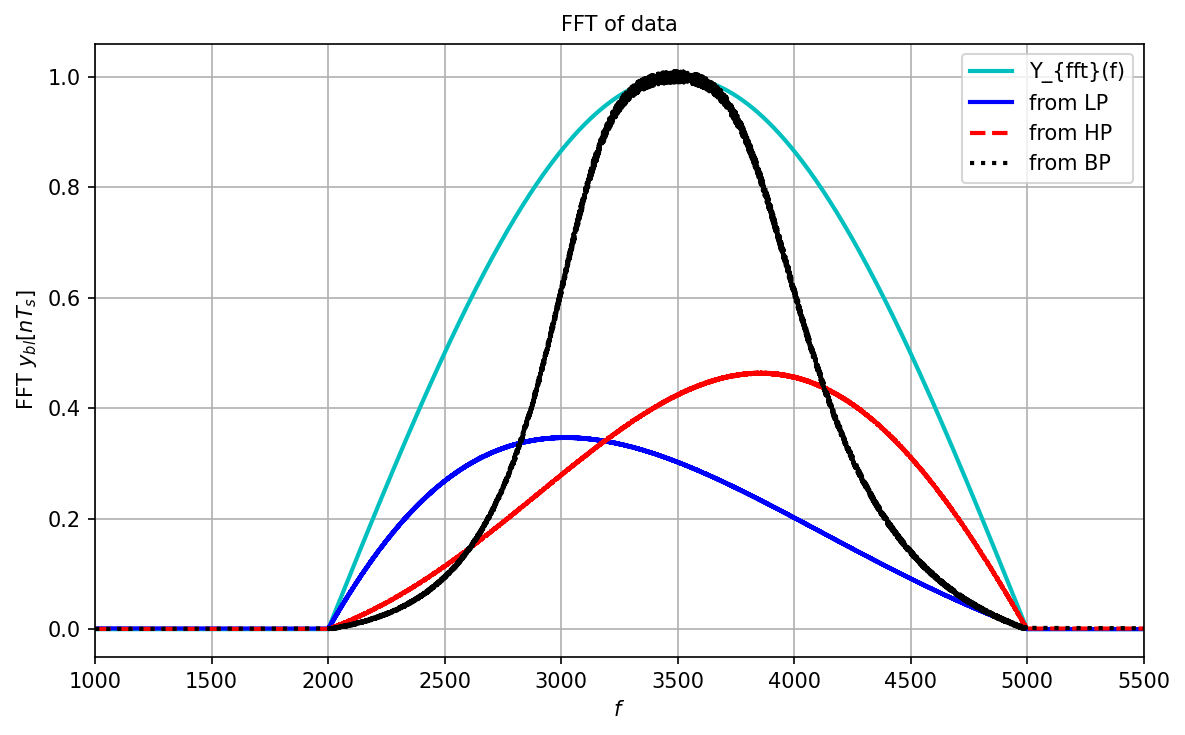

In [28]:
fig, ax1 = plt.subplots(1,1, figsize=(8,5), dpi=150)
ax1.plot(f_bl[0:N//2], np.abs(Y_bl_fft[0:N//2]),'c-')
ax1.plot(f_bl[0:N//2], np.abs(Y_lp_fft[0:N//2]),'b-')
ax1.plot(f_bl[0:N//2], np.abs(Y_hp_fft[0:N//2]),'r--')
ax1.plot(f_bl[0:N//2], np.abs(Y_bp_fft[0:N//2]),'k:')
ax1.set_ylabel('FFT $y_{bl}[nT_s]$')
ax1.set_xlabel('$f$')
ax1.set_xlim([int(f_low)/2, 1.1*int(f_high)])
ax1.legend(['Y_{fft}(f)','from LP','from HP','from BP'])
ax1.set_title('FFT of data')
plt.show()

In [29]:
from scipy.io.wavfile import write 

write("data/y_fft_sine.wav", fs, np.real(y_bl/max(y_bl)).astype(np.float32))
ipd.Audio('data/y_fft_sine.wav', rate = fs) 

In [30]:
write("data/yf_lp_fft_sine.wav", fs, np.real(yf_lp/max(yf_lp)).astype(np.float32))
ipd.Audio('data/yf_lp_fft_sine.wav', rate = fs) # 

In [31]:
write("data/yf_hp_fft_sine.wav", fs, np.real(yf_hp/max(yf_hp)).astype(np.float32))
ipd.Audio('data/yf_hp_fft_sine.wav', rate = fs) # 

In [32]:
write("data/yf_bp_fft_sine.wav", fs, np.real(yf_bp/max(yf_bp)).astype(np.float32))
ipd.Audio('data/yf_bp_fft_sine.wav', rate = fs) # 